In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/olist_cleaned.csv")

print("Shape:", df.shape)
print("Loaded successfully")

Shape: (115038, 37)
Loaded successfully


In [2]:
total_revenue = df['price'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = df['price'].mean()

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders:,}")
print(f"Average Order Value: R$ {avg_order_value:,.2f}")

Total Revenue: R$ 13,813,963.68
Total Unique Orders: 96,478
Average Order Value: R$ 120.08


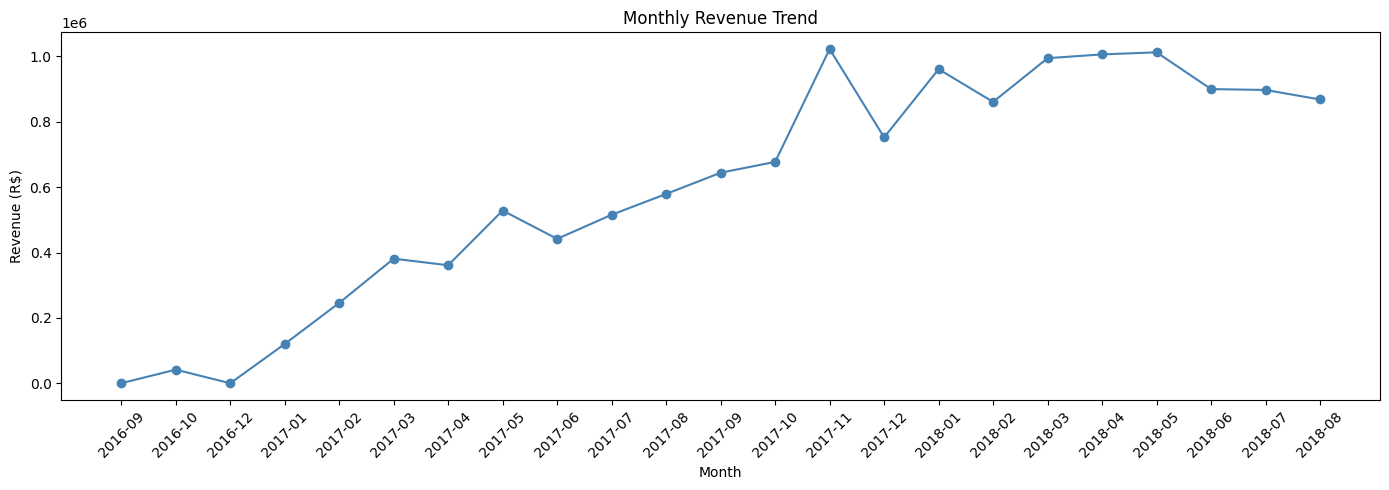

Chart saved


In [5]:
monthly_revenue = df.groupby(['order_year', 'order_month'])['price'].sum().reset_index()
monthly_revenue['period'] = monthly_revenue['order_year'].astype(str) + '-' + monthly_revenue['order_month'].astype(str).str.zfill(2)
monthly_revenue = monthly_revenue.sort_values('period')

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['period'], monthly_revenue['price'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.savefig("../reports/monthly_revenue.png")
plt.show()
print("Chart saved")

C:\Users\91990\AppData\Local\Temp\ipykernel_15444\4096654038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, x='price', y='product_category_name', palette='Blues_r')


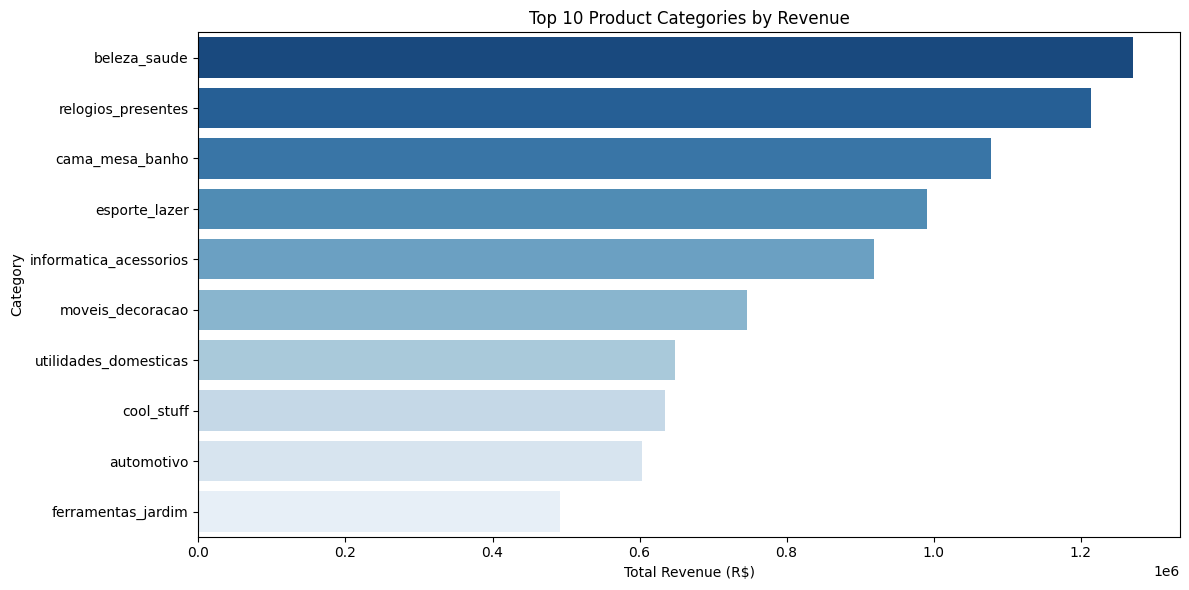

Chart saved


In [8]:
category_revenue = df.groupby('product_category_name')['price'].sum().reset_index()
category_revenue = category_revenue.sort_values('price', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, x='price', y='product_category_name', palette='Blues_r')
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("../reports/top_categories.png")
plt.show()
print("Chart saved")

C:\Users\91990\AppData\Local\Temp\ipykernel_15444\3693251600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_orders, x='order_id', y='customer_state', palette='Oranges_r')


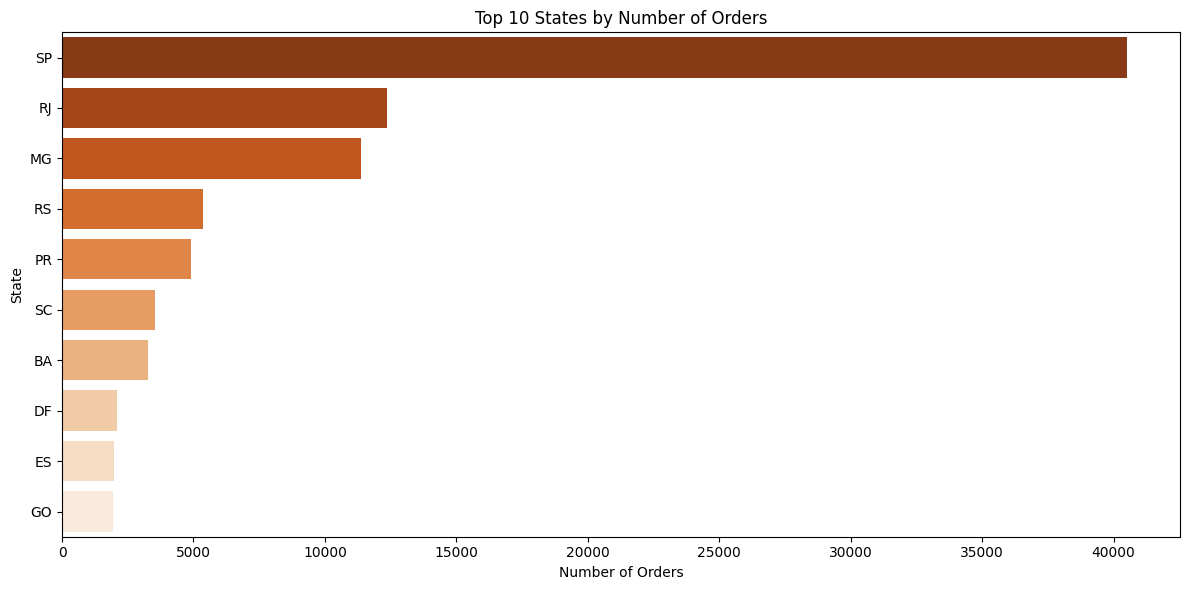

Chart saved


In [11]:
state_orders = df.groupby('customer_state')['order_id'].nunique().reset_index()
state_orders = state_orders.sort_values('order_id', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=state_orders, x='order_id', y='customer_state', palette='Oranges_r')
plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../reports/top_states.png")
plt.show()
print("Chart saved")

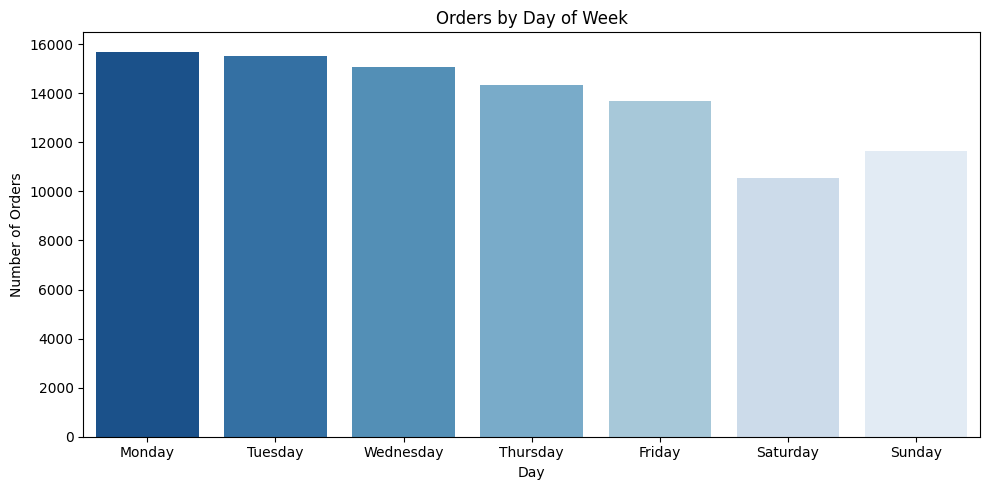

Chart saved


In [12]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df.groupby('order_day_of_week')['order_id'].nunique().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, hue=day_counts.index, palette='Blues_r', legend=False)
plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../reports/orders_by_day.png")
plt.show()
print("Chart saved")

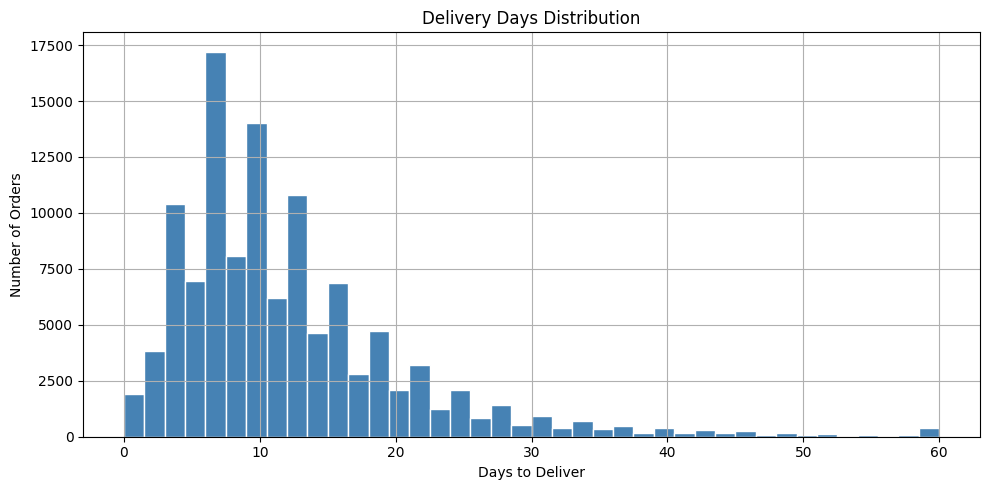

Average delivery days: 12.0
Median delivery days: 10.0


In [13]:
plt.figure(figsize=(10, 5))
df['delivery_days'].dropna().clip(0, 60).hist(bins=40, color='steelblue', edgecolor='white')
plt.title("Delivery Days Distribution")
plt.xlabel("Days to Deliver")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../reports/delivery_days.png")
plt.show()

print(f"Average delivery days: {df['delivery_days'].mean():.1f}")
print(f"Median delivery days: {df['delivery_days'].median():.1f}")